In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vaibhavsxn/google-stock-prices-training-and-test-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/google-stock-prices-training-and-test-data


In [4]:
#Loading the training data 
import pandas as pd
df = pd.read_csv('/kaggle/input/google-stock-prices-training-and-test-data/Google_Stock_Price_Train.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [5]:
#making sure there's no comma in the close column
df['Close'] = df['Close'].str.replace(',','').astype(float)


In [6]:
train_set = df.iloc[:,4:5].values
train_set

array([[663.59],
       [666.45],
       [657.21],
       ...,
       [785.05],
       [782.79],
       [771.82]])

In [7]:
#scaling 
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
train_set = sc.fit_transform(train_set)
train_set

array([[0.23757287],
       [0.24151427],
       [0.22878051],
       ...,
       [0.40495845],
       [0.40184391],
       [0.38672602]])

In [8]:
#the number of records in the train_Set
len(train_set)

1258

In [9]:
#Price existing tommorow will be the price for today
X_train = train_set[0:1257]
y_train = train_set[1:1258]



In [10]:
X_train,y_train

(array([[0.23757287],
        [0.24151427],
        [0.22878051],
        ...,
        [0.41391618],
        [0.40495845],
        [0.40184391]]),
 array([[0.24151427],
        [0.22878051],
        [0.21641884],
        ...,
        [0.40495845],
        [0.40184391],
        [0.38672602]]))

In [11]:
#Since RNN model expects 3D data we need to convert the 2D into 3D by adding TImestep:the frequency of data: 1day
import numpy as np

X_train = np.reshape(X_train,(1257,1,1))


In [12]:
X_train

array([[[0.23757287]],

       [[0.24151427]],

       [[0.22878051]],

       ...,

       [[0.41391618]],

       [[0.40495845]],

       [[0.40184391]]])

In [15]:
#inintializing the RNN model
from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense

model = Sequential([
    LSTM(units=100,return_sequences=True,input_shape=(None,1)),
    LSTM(units=50,return_sequences=True),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
    
])


In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, None, 100)      │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, None, 50)       │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#compiling the model 
model.compile(loss='mean_squared_error',optimizer='adam')

In [18]:
#Training the model
model.fit(X_train,y_train,batch_size= 20,epochs=100,verbose=2)

Epoch 1/100


I0000 00:00:1764235231.167209     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


63/63 - 4s - 62ms/step - loss: 0.0741
Epoch 2/100
63/63 - 0s - 5ms/step - loss: 0.0367
Epoch 3/100
63/63 - 0s - 5ms/step - loss: 0.0096
Epoch 4/100
63/63 - 0s - 5ms/step - loss: 0.0024
Epoch 5/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 6/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 7/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 8/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 9/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 10/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 11/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 12/100
63/63 - 0s - 5ms/step - loss: 0.0022
Epoch 13/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 14/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 15/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 16/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 17/100
63/63 - 0s - 6ms/step - loss: 0.0022
Epoch 18/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 19/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 20/100
63/63 - 0s - 5ms/step - loss: 0.0021
Epoch 21/100
63/63 -

In [19]:
#Testing on test data
test_set = pd.read_csv('/kaggle/input/google-stock-prices-training-and-test-data/Google_Stock_Price_Test.csv')
test_set

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"
5,1/10/2017,807.86,809.13,803.51,804.79,"1,176,800"
6,1/11/2017,805.00,808.15,801.37,807.91,"1,065,900"
7,1/12/2017,807.14,807.39,799.17,806.36,"1,353,100"
8,1/13/2017,807.48,811.22,806.69,807.88,"1,099,200"
9,1/17/2017,807.08,807.14,800.37,804.61,"1,362,100"


In [20]:
test_set = test_set.iloc[:,4:5]
test_set

,Close
0,786.14
1,786.90
2,794.02
3,806.15
4,806.65
5,804.79
6,807.91
7,806.36
8,807.88
9,804.61


In [21]:
#Scaling the test data
inputs = sc.transform(test_set)
inputs

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


array([[0.40646059],
       [0.40750796],
       [0.41732012],
       [0.43403663],
       [0.43472569],
       [0.4321624 ],
       [0.43646211],
       [0.43432603],
       [0.43642077],
       [0.43191434],
       [0.43392638],
       [0.42855174],
       [0.43247936],
       [0.45217259],
       [0.45845679],
       [0.47471852],
       [0.46986756],
       [0.45768505],
       [0.42875846],
       [0.42113749]])

In [22]:
#tranforming into 3D
inputs = np.reshape(inputs,(20,1,1))
inputs

array([[[0.40646059]],

       [[0.40750796]],

       [[0.41732012]],

       [[0.43403663]],

       [[0.43472569]],

       [[0.4321624 ]],

       [[0.43646211]],

       [[0.43432603]],

       [[0.43642077]],

       [[0.43191434]],

       [[0.43392638]],

       [[0.42855174]],

       [[0.43247936]],

       [[0.45217259]],

       [[0.45845679]],

       [[0.47471852]],

       [[0.46986756]],

       [[0.45768505]],

       [[0.42875846]],

       [[0.42113749]]])

In [23]:
#Predicting hte values
predicted_values = model.predict(inputs)
predicted_values

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


array([[[0.39143032]],

       [[0.39239457]],

       [[0.40144086]],

       [[0.41693082]],

       [[0.41757205]],

       [[0.41518793]],

       [[0.41918904]],

       [[0.4172001 ]],

       [[0.4191505 ]],

       [[0.4149573 ]],

       [[0.41682822]],

       [[0.411835  ]],

       [[0.4154825 ]],

       [[0.43389955]],

       [[0.4398299 ]],

       [[0.4553207 ]],

       [[0.45067644]],

       [[0.43910003]],

       [[0.41202685]],

       [[0.40496814]]], dtype=float32)

In [24]:
predicted_values = np.reshape(predicted_values,(20,1))
predicted_values

array([[0.39143032],
       [0.39239457],
       [0.40144086],
       [0.41693082],
       [0.41757205],
       [0.41518793],
       [0.41918904],
       [0.4172001 ],
       [0.4191505 ],
       [0.4149573 ],
       [0.41682822],
       [0.411835  ],
       [0.4154825 ],
       [0.43389955],
       [0.4398299 ],
       [0.4553207 ],
       [0.45067644],
       [0.43910003],
       [0.41202685],
       [0.40496814]], dtype=float32)

In [25]:
#Reshaping the output
test_pred = sc.inverse_transform(predicted_values)
test_pred

array([[775.23364],
       [775.9332 ],
       [782.4975 ],
       [793.7375 ],
       [794.20276],
       [792.47284],
       [795.37616],
       [793.93286],
       [795.34814],
       [792.3054 ],
       [793.6631 ],
       [790.03986],
       [792.6866 ],
       [806.0505 ],
       [810.3538 ],
       [821.59436],
       [818.2243 ],
       [809.82416],
       [790.1791 ],
       [785.057  ]], dtype=float32)

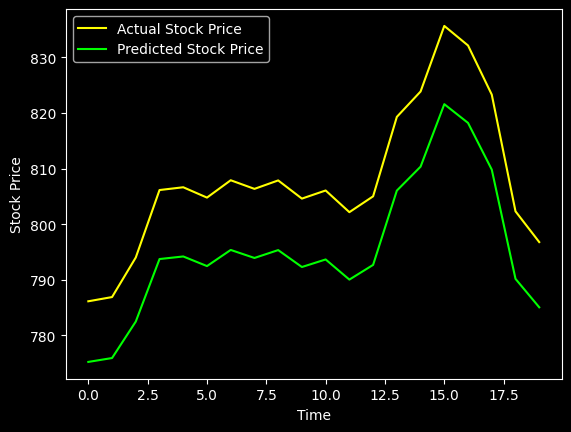

In [28]:
import matplotlib.pyplot as plt
plt.plot(test_set,color='yellow',label='Actual Stock Price')
plt.plot(test_pred,color='lime',label='Predicted Stock Price')
plt.xlabel("Time")
plt.ylabel('Stock Price')
plt.legend()
plt.style.use('dark_background')
plt.show()


In [32]:
model.save('my_model.keras')

In [33]:
#Importing the model
from keras.models import load_model
saved_model = load_model('my_model.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [34]:
#Predicting next day stock price
today_price = float(input("Enter today's stock price:"))

Enter today's stock price: 800


In [35]:
#Converting into 2d array
arr = np.reshape(today_price,(-1,1))
arr

array([[800.]])

In [36]:
#since predict method expects data to be in 3d we need to convert into 3d 
arr1 = np.reshape(arr,(-1,1,1))
result = model.predict(arr1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [37]:
#Result given by predict will be in 2d we need to reshape it again
result = np.reshape(result,(1,1))


In [38]:
result

array([[1.]], dtype=float32)

In [39]:
#We need inverse scaling
tomorrow_price = sc.inverse_transform(result)
print(tomorrow_price)

[[1216.83]]
